# AWG5208 sequence-list Gaussian delay sweep with `delay_auto()`

Every sequence step uses the same Gaussian pulse. Only the delay before the
pulse changes:

```text
step 1: anchor / delay_auto(0 ns)   / Gaussian
step 2: anchor / delay_auto(40 ns)  / Gaussian
step 3: anchor / delay_auto(80 ns)  / Gaussian
...
step 6: anchor / delay_auto(200 ns) / Gaussian
```

The marker remains at the beginning of every sequence step. ATS9371 therefore
captures a fixed 1 us window in which the Gaussian pulse moves from 0 to
200 ns. Records are reshaped to `(average, sequence_step, time)` and matching
traces are averaged along the first axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from awg_alazar import AWGAlazar
from awg5200 import (
    align_channels,
    delay_auto,
    gaussian,
    marker_window_ns,
    waveform,
)

## Experiment parameters

In [10]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
CARRIER_FREQUENCY_HZ = 50e6
ADC_CHANNEL = "CHB"

READOUT_CHANNEL = 3
MARKER_CHANNEL = 1
MARKER_NUMBER = 1
CHANNEL_AMPLITUDE_VPP = 0.5
MARKER_LOW_VOLTS = 0.0
MARKER_HIGH_VOLTS = 1.2

DELAY_VALUES_NS = np.arange(0, 201, 40)
GAUSSIAN_DURATION_NS = 100
GAUSSIAN_SIGMA_NS = 15
PULSE_PEAK_VOLTS = 0.02

# A one-sample zero anchor gives delay_auto() an end reference.
ANCHOR_SAMPLES = 1
SEQUENCE_STEP_NS = 1500
MARKER_WIDTH_NS = 40

ACQUIRE_WINDOW_NS = 1000
NUM_AVERAGES = 500
MOVING_AVERAGE_TIME_NS = 20
ALAZAR_TIMEOUT_MS = 60_000

## Connect and configure AWG5208 + ATS9371

In [11]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=CARRIER_FREQUENCY_HZ,
    trigger_delay_s=0.0,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=(0, ACQUIRE_WINDOW_NS),
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=MOVING_AVERAGE_TIME_NS * 1e-9,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("delay_auto values (ns):", DELAY_VALUES_NS.tolist())
print("ATS record:", experiment.acquire_window_cycles, "samples")
print("Total ATS records:", NUM_AVERAGES * len(DELAY_VALUES_NS))

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
delay_auto values (ns): [0, 40, 80, 120, 160, 200]
ATS record: 1024 samples
Total ATS records: 3000


## Build delayed Gaussian assets

The Gaussian envelope is identical in every step. A one-sample zero anchor is
followed by `delay_auto(delay_ns)`, then the Gaussian pulse. The rendered
waveform is padded to a fixed sequence-step duration.

Because the anchor lasts one DAC sample, the exact scheduled pulse start is
`delay_ns + 1 / AWG_SAMPLE_RATE_HZ`.

In [12]:
experiment.awg.clear_all()

step_samples = experiment.ns2cycles(SEQUENCE_STEP_NS, inst="dac")
gaussian_samples = experiment.ns2cycles(
    GAUSSIAN_DURATION_NS,
    inst="dac",
)
gaussian_envelope = gaussian(
    gaussian_samples,
    sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    sigma_s=GAUSSIAN_SIGMA_NS * 1e-9,
    amplitude_volts=PULSE_PEAK_VOLTS,
)

readout_assets = []
marker_assets = []
rendered_steps = []
scheduled_start_ns = []

for delay_ns in DELAY_VALUES_NS:
    anchor = waveform(
        np.zeros(ANCHOR_SAMPLES),
        fc=0.0,
        ch=MARKER_CHANNEL,
        name=f"anchor_{int(delay_ns)}ns",
    )
    pulse = waveform(
        gaussian_envelope,
        fc=CARRIER_FREQUENCY_HZ,
        ch=READOUT_CHANNEL,
        name=f"gaussian_{int(delay_ns)}ns",
    )
    timeline = (
        anchor
        / delay_auto(float(delay_ns) * 1e-9)
        / pulse
    )
    rendered = align_channels(
        timeline,
        sample_rate_hz=AWG_SAMPLE_RATE_HZ,
        total_duration_s=SEQUENCE_STEP_NS * 1e-9,
    )
    readout_values = rendered[READOUT_CHANNEL]
    marker_values = marker_window_ns(
        duration_ns=SEQUENCE_STEP_NS,
        sample_rate_hz=AWG_SAMPLE_RATE_HZ,
        start_ns=0,
        stop_ns=MARKER_WIDTH_NS,
    )

    suffix = f"{int(delay_ns)}ns"
    readout_assets.append(
        experiment.awg.upload_waveform_asset(
            name=f"seq_delay_readout_{suffix}",
            waveform_volts=readout_values,
            amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
        )
    )
    marker_assets.append(
        experiment.awg.upload_waveform_asset(
            name=f"seq_delay_marker_{suffix}",
            waveform_volts=rendered[MARKER_CHANNEL],
            amplitude_vpp=CHANNEL_AMPLITUDE_VPP,
            markers=(marker_values,),
        )
    )
    rendered_steps.append(readout_values)
    scheduled_start_ns.append(
        (ANCHOR_SAMPLES / AWG_SAMPLE_RATE_HZ + delay_ns * 1e-9) * 1e9
    )

rendered_steps = np.asarray(rendered_steps)
scheduled_start_ns = np.asarray(scheduled_start_ns)

print("Scheduled pulse starts (ns):", scheduled_start_ns.tolist())
print("Readout assets:", readout_assets)
print("Marker assets:", marker_assets)

Scheduled pulse starts (ns): [0.4, 40.4, 80.4, 120.40000000000002, 160.4, 200.40000000000003]
Readout assets: ['seq_delay_readout_0ns', 'seq_delay_readout_40ns', 'seq_delay_readout_80ns', 'seq_delay_readout_120ns', 'seq_delay_readout_160ns', 'seq_delay_readout_200ns']
Marker assets: ['seq_delay_marker_0ns', 'seq_delay_marker_40ns', 'seq_delay_marker_80ns', 'seq_delay_marker_120ns', 'seq_delay_marker_160ns', 'seq_delay_marker_200ns']


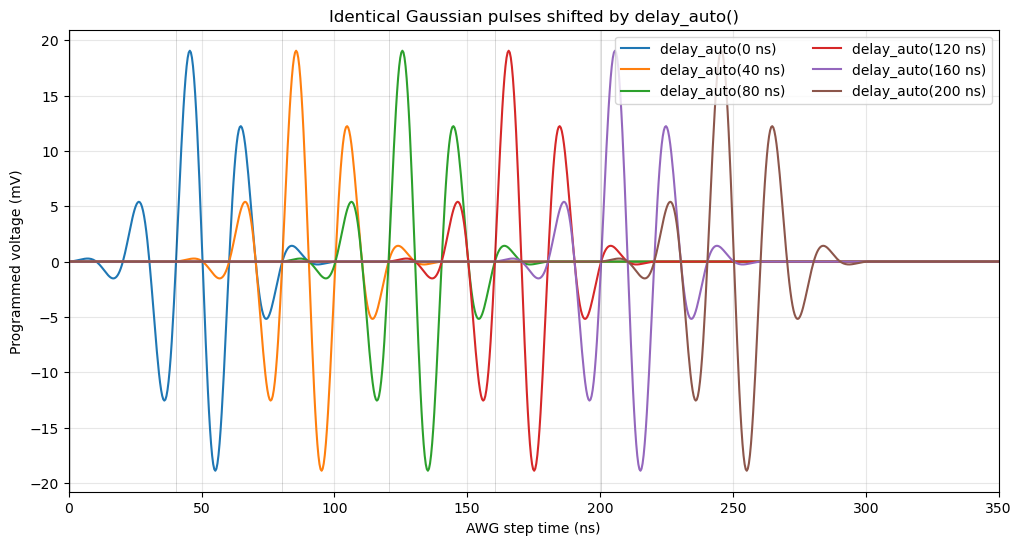

In [13]:
preview_time_ns = (
    np.arange(rendered_steps.shape[1])
    / AWG_SAMPLE_RATE_HZ
    * 1e9
)

plt.figure(figsize=(12, 6))
for step_index, delay_ns in enumerate(DELAY_VALUES_NS):
    plt.plot(
        preview_time_ns,
        rendered_steps[step_index] * 1e3,
        label=f"delay_auto({delay_ns} ns)",
    )
    plt.axvline(
        scheduled_start_ns[step_index],
        color="black",
        linewidth=0.5,
        alpha=0.2,
    )
plt.xlim(0, 350)
plt.xlabel("AWG step time (ns)")
plt.ylabel("Programmed voltage (mV)")
plt.title("Identical Gaussian pulses shifted by delay_auto()")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

## Create and assign the sequence list

In [14]:
experiment.awg.set_channel_amplitude(
    READOUT_CHANNEL,
    CHANNEL_AMPLITUDE_VPP,
)
experiment.awg.set_channel_resolution(READOUT_CHANNEL, 16)

experiment.awg.set_channel_amplitude(
    MARKER_CHANNEL,
    CHANNEL_AMPLITUDE_VPP,
)
experiment.awg.set_channel_resolution(
    MARKER_CHANNEL,
    16 - MARKER_NUMBER,
)
experiment.awg.set_marker_levels(
    MARKER_CHANNEL,
    MARKER_NUMBER,
    MARKER_LOW_VOLTS,
    MARKER_HIGH_VOLTS,
)

sequence_name = experiment.awg.create_sequence(
    "gaussian_delay_auto_sweep",
    tracks={
        MARKER_CHANNEL: marker_assets,
        READOUT_CHANNEL: readout_assets,
    },
    repetitions=1,
    goto_step=1,
)

print("Sequence:", sequence_name)
print("Steps:", len(DELAY_VALUES_NS))
print("Playback delays (ns):", DELAY_VALUES_NS.tolist())
print("AWG error:", experiment.awg.error())

Sequence: gaussian_delay_auto_sweep
Steps: 6
Playback delays (ns): [0, 40, 80, 120, 160, 200]
AWG error: 0,"No error"


## Acquire all interleaved records

The sequence loops through all delay values for each average:

```text
average 0: delay 0, 40, 80, 120, 160, 200 ns
average 1: delay 0, 40, 80, 120, 160, 200 ns
...
```

In [15]:
(
    raw_time_s,
    average_raw_traces,
    iq_time_s,
    average_iq_traces,
) = experiment.acquire_sequence_traces(
    number_of_steps=len(DELAY_VALUES_NS),
    number_of_averages=NUM_AVERAGES,
)

sequence_records = experiment.last_sequence_records_volts
sequence_shot_iq = experiment.last_sequence_shot_iq

print("Raw sequence records:", sequence_records.shape)
print("Raw averaged traces:", average_raw_traces.shape)
print("IQ sequence records:", sequence_shot_iq.shape)
print("IQ averaged traces:", average_iq_traces.shape)
print("AWG error:", experiment.awg.error())

Raw sequence records: (500, 6, 1024)
Raw averaged traces: (6, 1024)
IQ sequence records: (500, 6, 1005)
IQ averaged traces: (6, 1005)
AWG error: 0,"No error"


## Explicit trace-by-trace averaging

In [16]:
trace_by_trace_average = np.empty_like(average_raw_traces)

for step_index, delay_ns in enumerate(DELAY_VALUES_NS):
    matching_traces = sequence_records[:, step_index, :]
    trace_by_trace_average[step_index] = np.mean(
        matching_traces,
        axis=0,
    )
    print(
        f"delay_auto({delay_ns:3d} ns): "
        f"{matching_traces.shape[0]} traces averaged"
    )

np.testing.assert_allclose(
    trace_by_trace_average,
    average_raw_traces,
)
print("Trace-by-trace average verified.")

delay_auto(  0 ns): 500 traces averaged
delay_auto( 40 ns): 500 traces averaged
delay_auto( 80 ns): 500 traces averaged
delay_auto(120 ns): 500 traces averaged
delay_auto(160 ns): 500 traces averaged
delay_auto(200 ns): 500 traces averaged
Trace-by-trace average verified.


## Plot averaged raw ADC traces

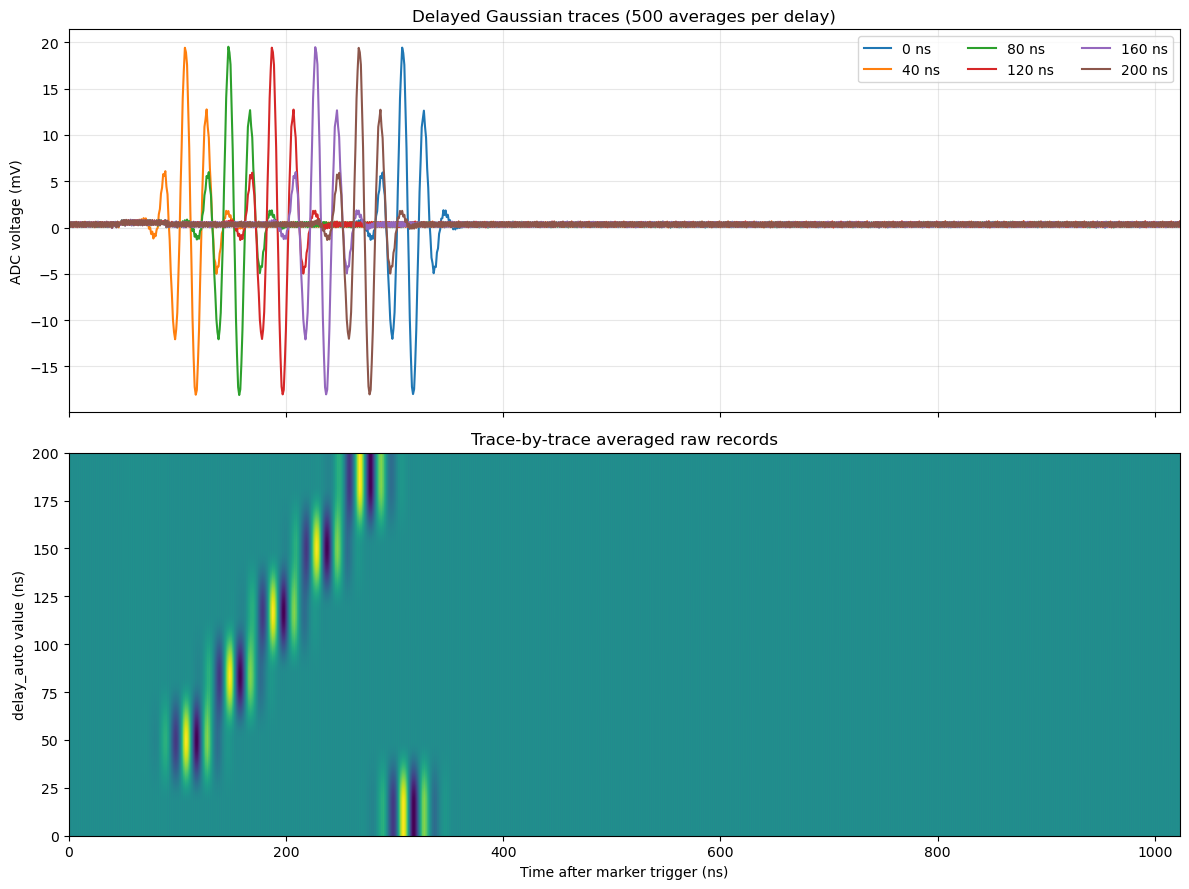

In [17]:
raw_time_ns = raw_time_s * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for step_index, delay_ns in enumerate(DELAY_VALUES_NS):
    axes[0].plot(
        raw_time_ns,
        average_raw_traces[step_index] * 1e3,
        label=f"{delay_ns} ns",
    )
axes[0].set_ylabel("ADC voltage (mV)")
axes[0].set_title(
    f"Delayed Gaussian traces ({NUM_AVERAGES} averages per delay)"
)
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3)

axes[1].imshow(
    average_raw_traces * 1e3,
    aspect="auto",
    origin="lower",
    extent=[
        raw_time_ns[0],
        raw_time_ns[-1],
        DELAY_VALUES_NS[0],
        DELAY_VALUES_NS[-1],
    ],
)
axes[1].set_xlabel("Time after marker trigger (ns)")
axes[1].set_ylabel("delay_auto value (ns)")
axes[1].set_title("Trace-by-trace averaged raw records")

plt.tight_layout()
plt.show()

## Plot moving-averaged IQ envelopes

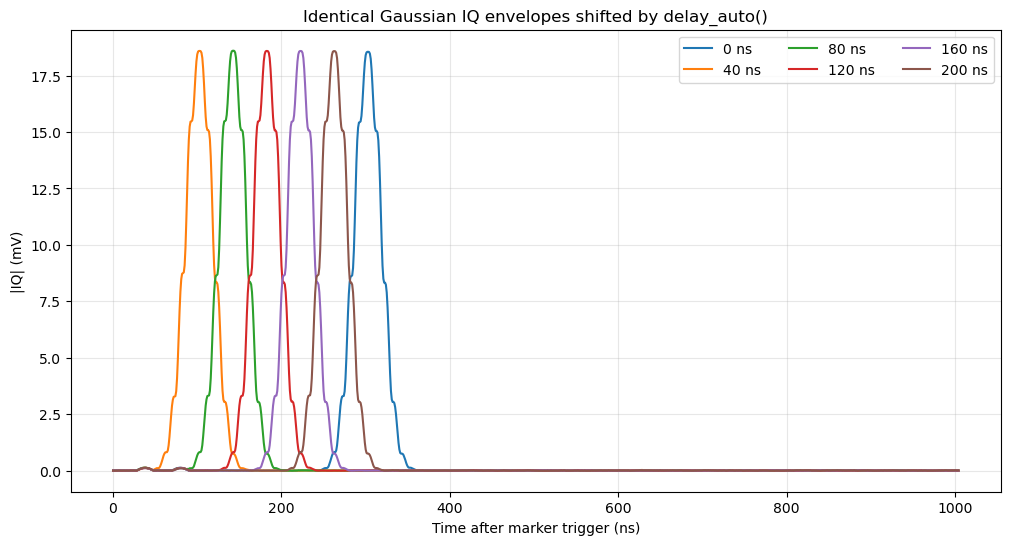

In [18]:
iq_time_ns = iq_time_s * 1e9

plt.figure(figsize=(12, 6))
for step_index, delay_ns in enumerate(DELAY_VALUES_NS):
    plt.plot(
        iq_time_ns,
        np.abs(average_iq_traces[step_index]) * 1e3,
        label=f"{delay_ns} ns",
    )
plt.xlabel("Time after marker trigger (ns)")
plt.ylabel("|IQ| (mV)")
plt.title("Identical Gaussian IQ envelopes shifted by delay_auto()")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
plt.show()

## Save the sequence acquisition

In [ ]:
np.savez(
    "sequence_delay_auto_capture.npz",
    delay_values_ns=DELAY_VALUES_NS,
    scheduled_start_ns=scheduled_start_ns,
    raw_time_s=raw_time_s,
    sequence_records_volts=sequence_records,
    average_raw_traces=average_raw_traces,
    iq_time_s=iq_time_s,
    sequence_shot_iq=sequence_shot_iq,
    average_iq_traces=average_iq_traces,
)
print("Saved sequence_delay_auto_capture.npz")

## Close hardware sessions

In [ ]:
experiment.close()
print("AWG VISA session closed")